In [1]:
import numpy as np
import pandas as pd
from src.processing import calculate_fitness, find_pareto_front
from src.visualization import display_pareto_front, display_fitness_landscape_with_pareto

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5


In [2]:
total_records = 10000000

# Parametrizar todas as equações por total_records
# Proporções calculadas com base em total_records = 10,000,000
equations1 = [
    lambda x: (x/(total_records * 0.05))**2 / 70,       # 500000 = total_records/20
    lambda x: 10 * np.cos(x/(total_records * 3)),       # 30000000 = total_records*3
    lambda x:  7 * np.cos(x/(total_records * 1)),       # 10000000 = total_records*1
    lambda x:  4 * np.cos(x/(total_records * 0.4)),     # 4000000 = total_records*0.4
    lambda x:  5 * np.cos(x/(total_records * 0.1)),     # 1000000 = total_records/10
    lambda x:  5 * np.cos(x/(total_records * 0.05)),    # 500000 = total_records/20
    lambda x:  4 * np.sin(x/(total_records * 0.01)),    # 100000 = total_records/100
    lambda x:  3 * np.cos(x/(total_records * 0.0025)),  # 25000 = total_records/400
    lambda x:  2 * np.cos(x/(total_records * 2 * 0.0004)),  # 4000 = total_records/2500
    lambda x:      np.sin(x/(total_records * 2 * 0.0002)),  # 2000 = total_records/5000
    lambda x: np.maximum(0, 3 * np.cos(2.3+ (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: np.maximum(0, 3 * np.sin(1  + (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: 5,
]

equations2 = [
#    lambda x: (x/(total_records * 0.1))**2 / 140,       # 500000 = total_records/20
    lambda x: (5**(-x/total_records))*3,
    lambda x: 10 * np.sin(x/(total_records * 3)),       # 30000000 = total_records*3
    lambda x:  7 * np.sin(x/(total_records * 1)),       # 10000000 = total_records*1
    lambda x:  2 * np.sin(x/(total_records * 0.4)),     # 4000000 = total_records*0.4
    lambda x:  2 * np.sin(x/(total_records * 0.2)),     # 2000000 = total_records/5
    lambda x:  2 * np.sin(x/(total_records * 0.1)),     # 1000000 = total_records/10
    lambda x:  2 * np.cos(x/(total_records * 0.03)),    # 300000 = total_records*0.03
    lambda x:  2 * np.cos(x/(total_records * 0.005)),   # 50000 = total_records/200
    lambda x:      np.sin(x/(total_records * 0.002)),   # 20000 = total_records/500
    lambda x:      np.cos(x/(total_records * 2 * 0.0008)),  # 8000 = total_records/1250
    lambda x: np.minimum(0, 3 * np.cos(2.3+ (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: np.minimum(0, 3 * np.sin(1  + (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: 5,
]

In [3]:
#### Criando dataframe com registros de 0 a 9999999
tamanho = len(str(total_records))-1
registros = np.arange(0, total_records, dtype=np.int32)
df = pd.DataFrame({'registro': registros})
print(f"Range: {registros[0]:,} até {registros[-1]:,}")

#### Calculando fitness de forma matricial
df = calculate_fitness(equations1, equations2, df)
df['fitness1'] /= 2.5
df['fitness2'] /= 1.1
df['fitness_full'] = df['fitness1'] + df['fitness2']
print(f"Colunas: {list(df.columns)}")

Range: 0 até 9,999,999
Colunas: ['registro', 'eq1_0', 'eq1_1', 'eq1_2', 'eq1_3', 'eq1_4', 'eq1_5', 'eq1_6', 'eq1_7', 'eq1_8', 'eq1_9', 'eq1_10', 'eq1_11', 'eq1_12', 'eq2_0', 'eq2_1', 'eq2_2', 'eq2_3', 'eq2_4', 'eq2_5', 'eq2_6', 'eq2_7', 'eq2_8', 'eq2_9', 'eq2_10', 'eq2_11', 'eq2_12', 'fitness1', 'fitness2', 'fitness_full']


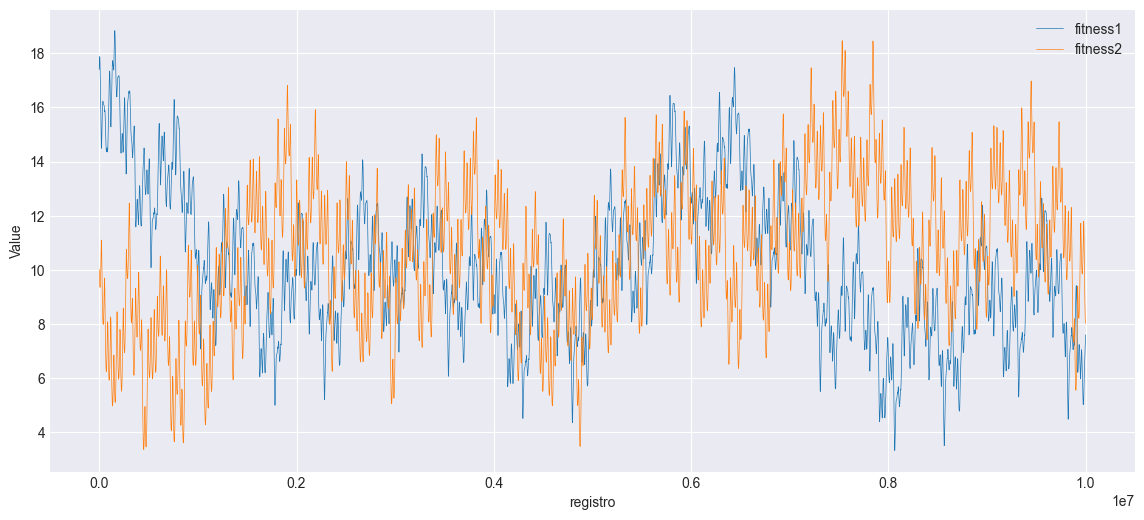

In [4]:
#plt.plot(df2['registro'], df2['log'], label='log')
plt.plot(df['registro'], df['fitness1'], label='fitness1')
plt.plot(df['registro'], df['fitness2'], label='fitness2')

plt.xlabel('registro')
plt.ylabel('Value')
plt.legend()
plt.show()

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 10,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 43,958 pontos.
Isso representa 0.4396% do espaço de busca.


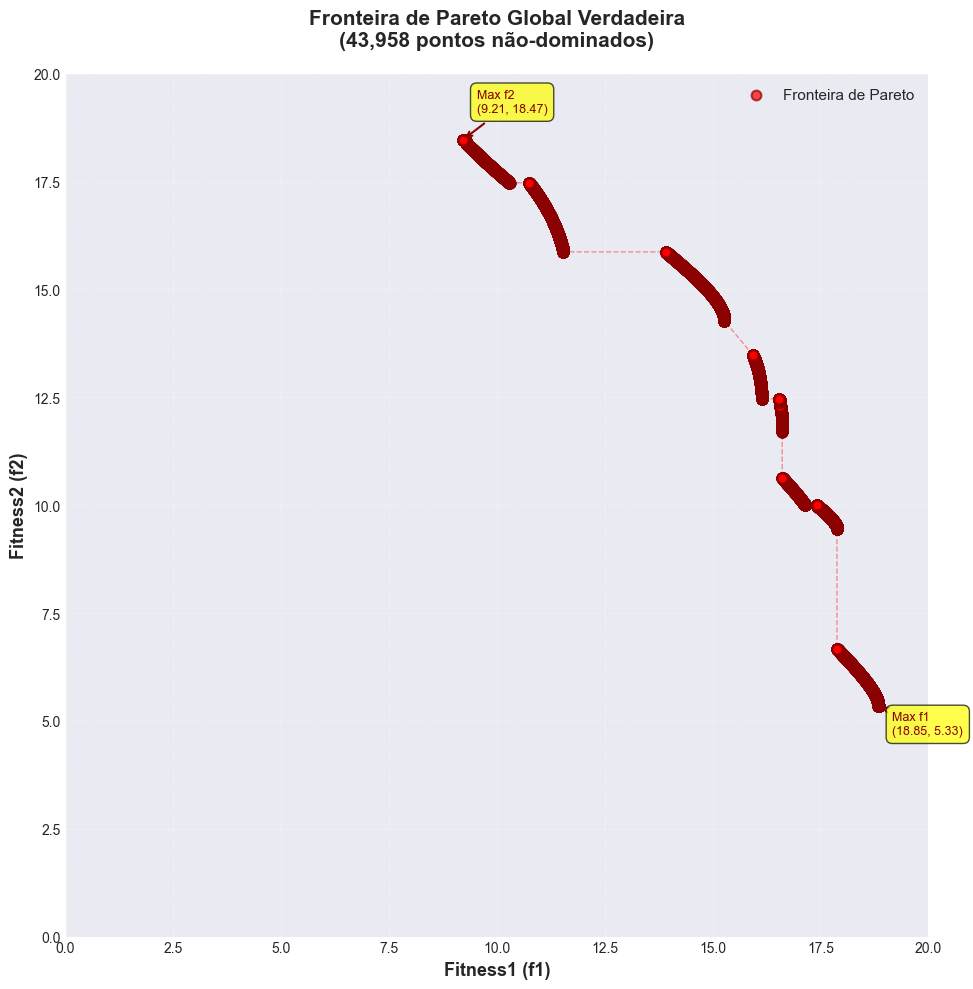


✅ Visualização concluída!


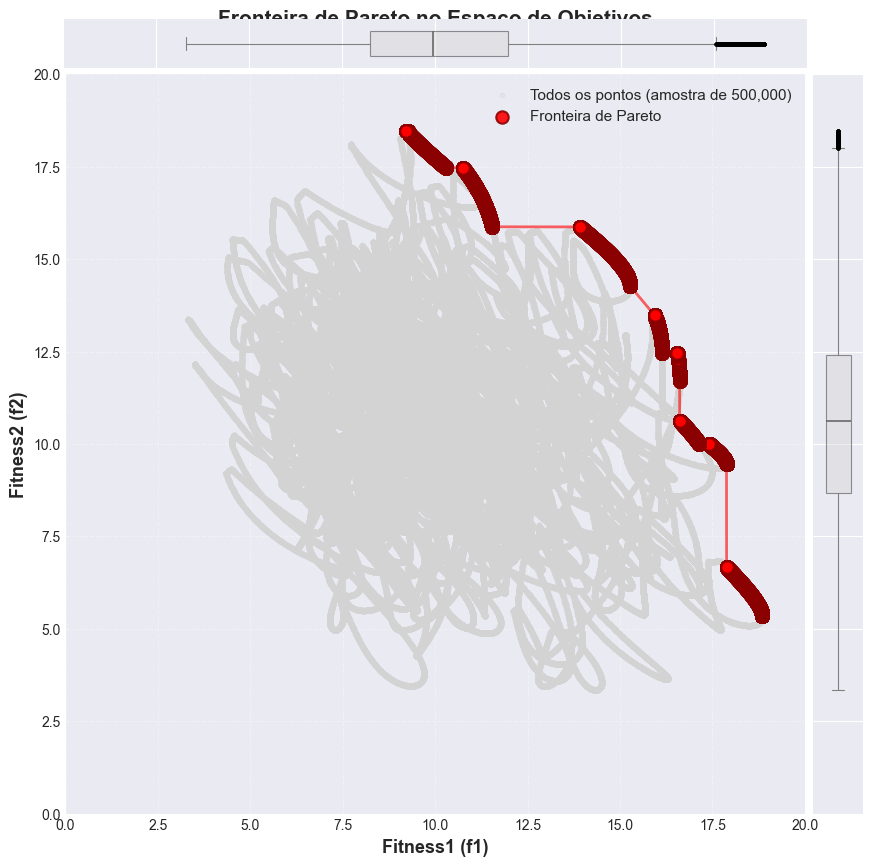

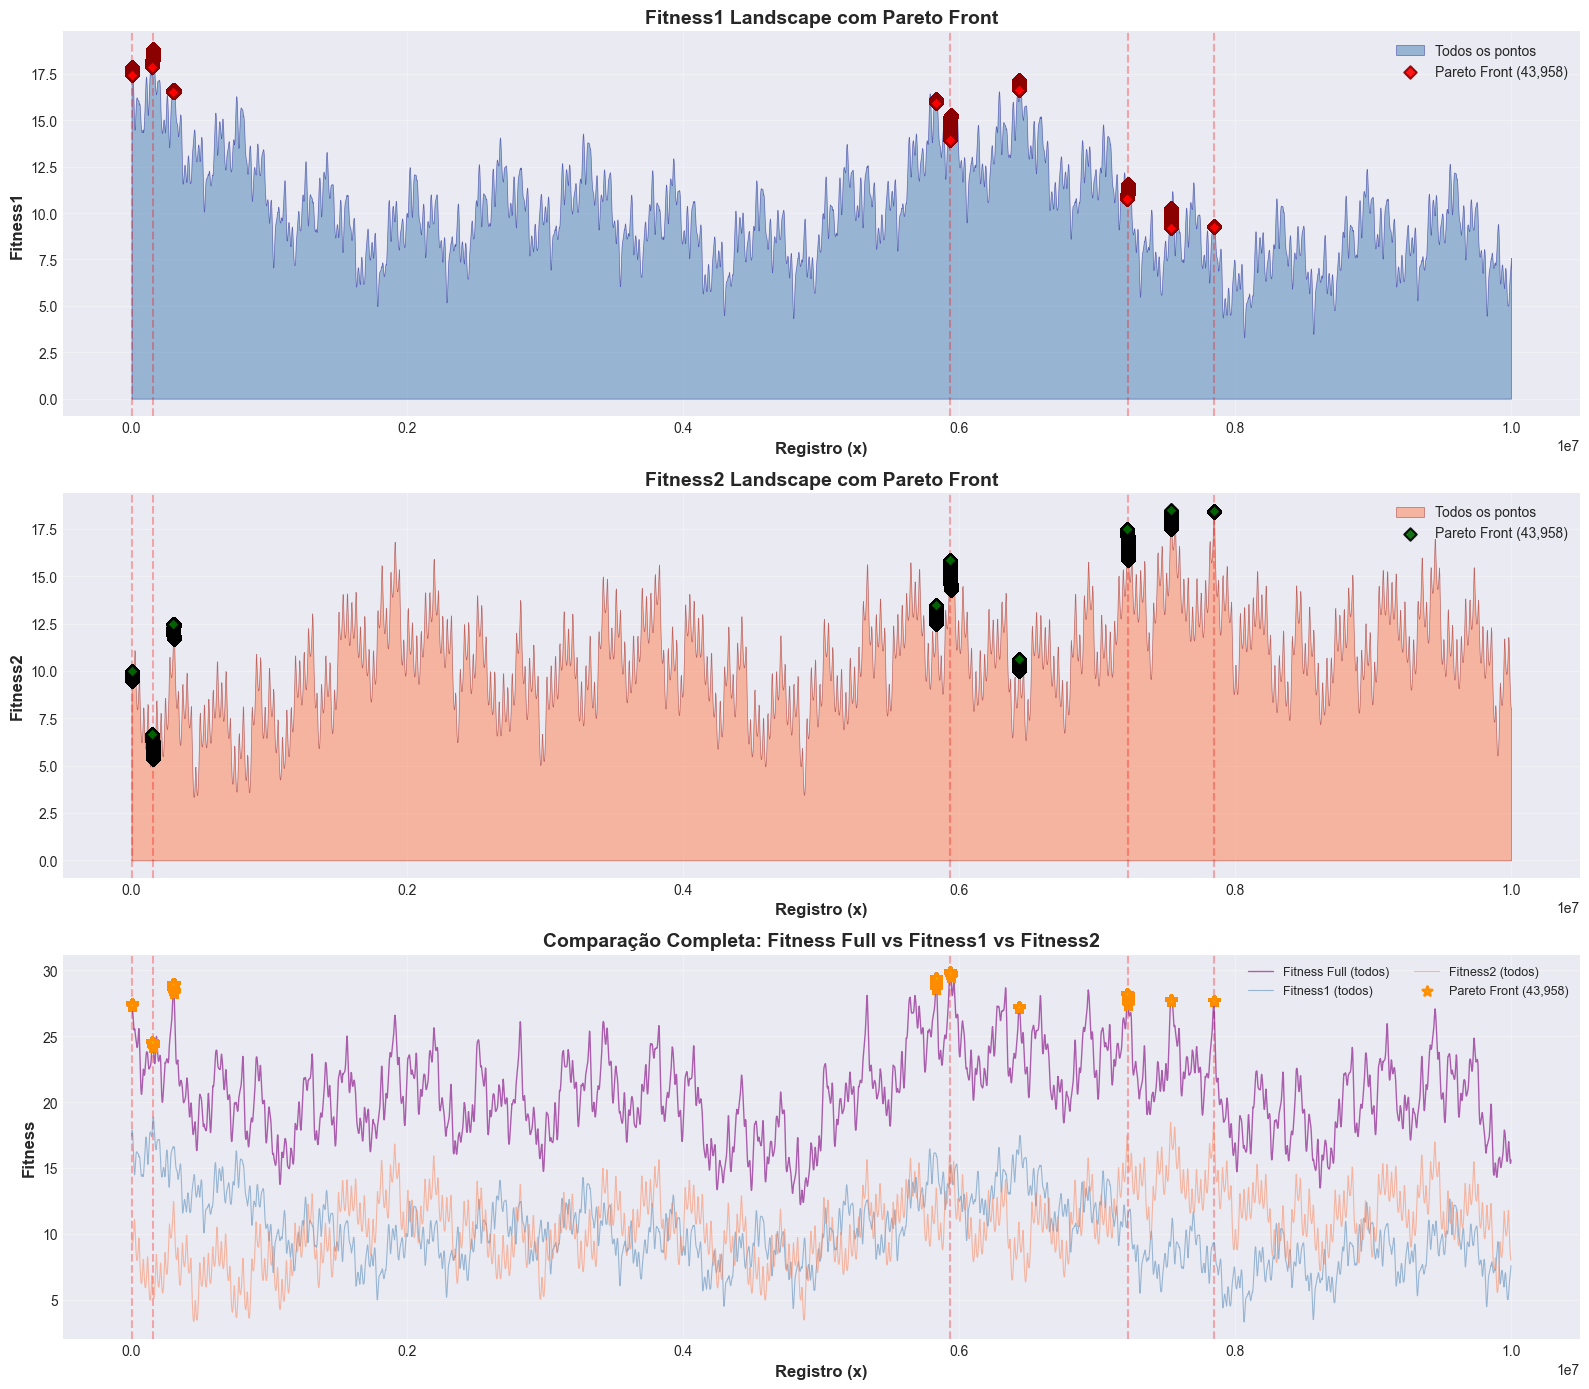

In [5]:
#### Encontrando a fronteira de Pareto verdadeira
pareto_df = find_pareto_front(df)
display_pareto_front(df, pareto_df)
display_fitness_landscape_with_pareto(df, pareto_df)

#### Salvando resultados
df.to_parquet('data/df.parquet')
pareto_df.to_parquet('data/pareto_df.parquet')